# Horn genome mega-plot

Per-chromosome tracks for the **final de-novo assembly** `10-horn-final.renamed.fa`:

- **GenMap mappability** (green, 0–1)
- **TRF tandem-repeat fraction** (blue)
- **RepeatOBserver Shannon diversity** (purple, min-max normalised)
- **nanopore coverage** (brown; 0.5 = genome-median depth)
- **LAI** (orange, right twin axis, real units — LTR_retriever 3 Mb windows)
- **v2r hits**: tblastn = red vertical lines, pHMM intact genes = pink


In [ ]:
%matplotlib inline
import numpy as np, matplotlib, glob
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

def resolve(path):
    """Return path if it exists, else search by basename under its top dir (dir keeps moving)."""
    import os
    if os.path.exists(path): return path
    base = os.path.basename(path)
    for root in ("/hpcfs/users/a1864358/sanders_lab/asm/files/annotation", os.path.dirname(path)):
        hits = glob.glob(f"{root}/**/{base}", recursive=True)
        if hits: return hits[0]
    return path

def resolve(path):
    """Return path if it exists, else search by basename under its top dir (dir keeps moving)."""
    import os
    if os.path.exists(path): return path
    base = os.path.basename(path)
    for root in ("/hpcfs/users/a1864358/sanders_lab/asm/files/annotation", os.path.dirname(path)):
        hits = glob.glob(f"{root}/**/{base}", recursive=True)
        if hits: return hits[0]
    return path


## Config — inputs, chromosomes, constants
`BLAST_RENAME` maps the raw `10-horn-final.fa` bed labels to final naming: `ch6→chZ`, and `ch4↔ch5` (the raw bed is swapped vs the renamed assembly; verified against pHMM-intact).


In [67]:
BIN = 1_000_000
CHROMS = ["ch1","ch2","ch3","ch4","ch5","ch7","ch8","chZ"]
FAI = "/scratchdata1/users/a1864358/sanders_lab/asm/files/final-asms/10-horn-final.renamed.fa.fai"
TRF = "trf_horn/horn.trf.ngs.dat"
MAP = "genmap/final_map_K30_E2/final.mappability.1Mb.tsv"
SHA = "robserver_horn_shannon.tsv"
LAI = "/scratchdata1/users/a1864358/sanders_lab/repeatdensity-atv2rs/edta_run/10-horn-final.renamed.fa.mod.out.LAI"
V2R_BLAST = "/hpcfs/users/a1864358/sanders_lab/asm/files/annotation/tblastn/final/horn_v2r_loci.bed"
        # new = 
V2R_HMM   = "/hpcfs/users/a1864358/sanders_lab/v2r_hmm/validation/intact/horn_v2r_genes.csv"
COV = "horn_cov.1Mb.tsv"   # mean nanopore depth per 1 Mb (mosdepth, mapped to ch names)
# tblastn bed uses the NON-renamed 10-horn-final.fa chromosome labels:
#   ch6 = Z; ch4<->ch5 are swapped relative to the final renamed assembly
# (verified: pHMM-intact puts the V2R cluster on renamed ch4=36, tblastn raw bed on ch5=90).
BLAST_RENAME = {"ch6": "chZ", "ch4": "ch5", "ch5": "ch4"}


## Chromosome lengths + TRF tandem-repeat coverage (per 1 Mb)


In [ ]:
length = {}
for ln in open(FAI):
    f = ln.split("\t"); length[f[0]] = int(f[1])
nbins = {c: length[c]//BIN + 1 for c in CHROMS}

# RF coverage (merged) per 1Mb
ivals = {c: [] for c in CHROMS}; cur = None
for line in open(TRF):
    if line[0] == "@": cur = line[1:].strip(); continue
    if cur not in ivals: continue
    p = line.split(); s, e = int(p[0]), int(p[1])
    if e < s: s, e = e, s
    ivals[cur].append((s, e))
    
def cov_track(iv, glen):
    out = np.zeros(glen//BIN + 1)
    if not iv: return out
    iv = sorted(iv); cs, ce = iv[0]; merged = []
    for s, e in iv[1:]:
        if s <= ce+1: ce = max(ce, e)
        else: merged.append((cs, ce)); cs, ce = s, e
    merged.append((cs, ce))
    for s, e in merged:
        for b in range(s//BIN, e//BIN + 1):
            lo = max(s, b*BIN); hi = min(e, (b+1)*BIN - 1); out[b] += hi-lo+1
    return out
trf = {c: 100.0*cov_track(ivals[c], length[c])/BIN for c in CHROMS}


## GenMap mappability (mean per 1 Mb)


In [ ]:
# GenMap mean mappability per 1Mb
mapp = {c: np.full(nbins[c], np.nan) for c in CHROMS}
for ln in open(MAP):
    c, b, v, cov = ln.split("\t")
    if c in mapp and int(b) < nbins[c]:
        mapp[c][int(b)] = float(v)


## RepeatOBserver Shannon diversity (mean per 1 Mb)


In [ ]:
# RepeatOBserver Shannon: mean per 1Mb
ssum = {c: np.zeros(nbins[c]) for c in CHROMS}
scnt = {c: np.zeros(nbins[c]) for c in CHROMS}
hdr = True
for ln in open(SHA):
    if hdr: hdr = False; continue
    c, pos, h = ln.split("\t")
    if c in ssum:
        b = int(pos)//BIN
        if b < nbins[c]: ssum[c][b] += float(h); scnt[c][b] += 1
sha = {c: np.divide(ssum[c], scnt[c], out=np.full(nbins[c], np.nan), where=scnt[c]>0) for c in CHROMS}


## LAI per sliding window (LTR_retriever)


In [ ]:
# LAI per sliding window (center in Mb -> x, value = LAI col7)
lai_x = {c: [] for c in CHROMS}; lai_y = {c: [] for c in CHROMS}
hdr = True
for ln in open(LAI):
    if hdr: hdr = False; continue
    f = ln.rstrip("\n").split("\t")
    c = f[0]
    if c not in lai_x: continue
    frm, to, lai = int(f[1]), int(f[2]), f[6]
    if lai in ("", "NA", "NaN"): continue
    lai_x[c].append(((frm + to) / 2) / BIN)
    lai_y[c].append(float(lai))


## v2r hits — tblastn (red) and pHMM intact genes (pink)


In [ ]:
# v2r hit positions (midpoint in Mb)
def load_positions_bed(path, rename):
    d = {c: [] for c in CHROMS}
    for ln in open(path):
        f = ln.split("\t")
        c = rename.get(f[0], f[0])
        if c in d:
            d[c].append(((int(f[1]) + int(f[2])) / 2) / BIN)
    return d

def load_intact_genes(path):
    # cols: scaffold,start,end,strand,query_cov,identity,frameshifts,stop_codons,class,best_query
    d = {c: [] for c in CHROMS}; hdr = True
    for ln in open(path):
        if hdr: hdr = False; continue
        f = ln.rstrip("\n").split(",")
        if f[8] != "intact": continue
        if f[0] in d:
            d[f[0]].append(((int(f[1]) + int(f[2])) / 2) / BIN)
    return d
v2r_blast = load_positions_bed(resolve(V2R_BLAST), BLAST_RENAME)
v2r_hmm   = load_intact_genes(V2R_HMM)


## Nanopore coverage (mean depth per 1 Mb)
Pre-binned in `horn_cov.1Mb.tsv` (mosdepth per-base → 1 Mb, contigs mapped to `ch*` by length).


In [ ]:
# mean nanopore coverage per 1Mb
cov = {c: np.full(nbins[c], np.nan) for c in CHROMS}
for ln in open(COV):
    c, b, d = ln.split("\t")
    if c in cov and int(b) < nbins[c]:
        cov[c][int(b)] = float(d)
_allcov = np.concatenate([cov[c][~np.isnan(cov[c])] for c in CHROMS])
COV_MED = np.median(_allcov) if _allcov.size else 1.0  # 0.5 axis = genome median depth


## Plot helpers


In [74]:
mb = lambda x, _: f"{x*BIN/1e6:.0f}"
maxb = max(nbins[c] for c in CHROMS)

def norm(a):
    a = np.array(a, dtype=float); m = np.nanmin(a); M = np.nanmax(a)
    return (a-m)/(M-m) if M > m else np.zeros_like(a)

LAI_MAX = 50.0  # twin-axis cap (whole-genome LAI 24.6; windows peak ~46)
RED  = "red"
PINK = "blue"


In [ ]:
# tandem array regions — green track below x-axis (from TRF .ngs.dat)
#

#   light green = TRF call alone
#   dark  green = TRF call corroborated by genmap (low mappability) +
#                 nanopore coverage (anomalous depth) + RepeatOBserver
#                 (low Shannon diversity — tandem arrays are low-complexity)


TA_COLOR        = "#a1d99b"   
TA_STRONG_COLOR = "#00441b"   
TA_YBOT, TA_YTOP = -0.24, -0.06          # strip height in main-axes y coords (taller)
TA_X = None                               # bp lower bound (None = no limit)
TA_Y = None                               # bp upper bound (None = no limit)

# corroboration thresholds (per 1 Mb bin) 
TA_TRF_MIN_FRAC = 1.0    # TRF: bin tandem-repeat fraction (%) must exceed this
TA_MAP_MAX      = 0.5    # genmap: mappability below this counts as "low" (repetitive)
TA_COV_DEV      = 0.3    # coverage: |depth/median - 1| above this counts as anomalous
TA_SHA_MAX      = 0.5    # RepeatOBserver: normalised Shannon diversity below this counts as "low"


def load_trf_arrays(trf_path=TRF, chroms=None):
    """Parse TRF -ngs output → {chrom: [(start, end), ...]} (1-based bp, inclusive)."""
    chroms = chroms or CHROMS
    out = {c: [] for c in chroms}
    cur = None
    with open(trf_path) as fh:
        for line in fh:
            if line.startswith("@"):
                cur = line[1:].strip()
                continue
            if cur not in out:
                continue
            p = line.split()
            s, e = int(p[0]), int(p[1])
            if e < s:
                s, e = e, s
            out[cur].append((s, e))
    return out


def filter_ta_intervals(intervals, x=None, y=None, mode="overlap"):
    """
    Keep tandem arrays in genomic window defined by x and y (bp).
    """
    out = []
    for s, e in intervals:
        if x is not None and y is not None:
            if mode == "inside":
                if not (s > x and e < y):
                    continue
            elif e <= x or s >= y:
                continue
        elif x is not None and e <= x:
            continue
        elif y is not None and s >= y:
            continue
        out.append((s, e))
    return out


def mask_to_bp_intervals(mask):
    """Boolean per-bin array → merged [start_bp, end_bp) runs of True bins."""
    out = []
    n = len(mask)
    i = 0
    while i < n:
        if mask[i]:
            j = i
            while j < n and mask[j]:
                j += 1
            out.append((i * BIN, j * BIN))
            i = j
        else:
            i += 1
    return out


def corroborated_mask(c):
    """Per-bin bool: TRF tandem call AND low mappability AND coverage anomaly AND low Shannon diversity."""
    n = nbins[c]
    m_trf = trf[c] > TA_TRF_MIN_FRAC
    m_map = np.nan_to_num(mapp[c], nan=1.0) < TA_MAP_MAX
    m_cov = np.abs(np.nan_to_num(cov[c], nan=COV_MED) / COV_MED - 1) > TA_COV_DEV
    m_sha = np.nan_to_num(norm(sha[c]), nan=1.0) < TA_SHA_MAX
    return m_trf & m_map & m_cov & m_sha


def plot_ta_track(ax, intervals, *, y_bot=TA_YBOT, y_top=TA_YTOP,
                  color=TA_COLOR, alpha=0.88, zorder=15, extend_ylim=True):
    """
    Overlay tandem-array boundaries as rectangles in a strip below the x-axis.
    x-axis data coords = 1 Mb bin index (genomic_bp / BIN).
    """
    if not intervals:
        return ax
    segs = [(s / BIN, (e - s) / BIN) for s, e in intervals]
    ax.broken_barh(segs, (y_bot, y_top - y_bot),
                   facecolors=color, edgecolors="none", alpha=alpha, zorder=zorder)
    if extend_ylim:
        lo, hi = ax.get_ylim()
        ax.set_ylim(min(lo, y_bot - 0.02), hi)
    return ax


# build per-chromosome arrays (reuse ivals if TRF cell already ran)
try:
    ta_arrays = {c: list(ivals[c]) for c in CHROMS}
except NameError:
    ta_arrays = load_trf_arrays(TRF)

ta_display = {c: filter_ta_intervals(ta_arrays[c], TA_X, TA_Y) for c in CHROMS}

# corroborated subset: TRF + genmap + coverage + RepeatOBserver all agree
ta_strong_arrays = {c: mask_to_bp_intervals(corroborated_mask(c)) for c in CHROMS}
ta_strong_display = {c: filter_ta_intervals(ta_strong_arrays[c], TA_X, TA_Y) for c in CHROMS}


### plot


In [76]:
def plot_chromosome_panel(ax, c, *, xlim=None, show_ylabel=True):
    """Draw all mega-plot tracks + tandem-array strip for one chromosome."""
    if xlim is None:
        xlim = (0, nbins[c])
    x = np.arange(nbins[c])
    for px in v2r_hmm[c]:
        ax.axvline(px, color=PINK, lw=0.4, alpha=0.7, zorder=0)
    for px in v2r_blast[c]:
        ax.axvline(px, color=RED, lw=0.4, alpha=0.3, zorder=1)
    ax.plot(x, mapp[c],      color="#1b7837", lw=0.8, zorder=3)
    ax.plot(x, trf[c]/100.0, color="#2b6cb0", lw=0.8, zorder=3)
    ax.plot(x, norm(sha[c]), color="#762a83", lw=0.8, zorder=3)
    ax.plot(x, np.clip(cov[c]/(2*COV_MED), 0, 1.05), color="#8c564b", lw=0.8, zorder=3)
    plot_ta_track(ax, ta_display[c])
    plot_ta_track(ax, ta_strong_display[c], color=TA_STRONG_COLOR, alpha=0.88, zorder=15)
    ax.set_xlim(*xlim)
    ax.set_ylim(min(TA_YBOT - 0.02, -0.05), 1.05)
    if show_ylabel:
        ax.set_ylabel(f"{c}\n{length[c]/1e6:.0f} Mb", rotation=0, ha="right", va="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax2 = ax.twinx()
    if lai_x[c]:
        ax2.plot(lai_x[c], lai_y[c], color="#ff7f0e", lw=0.9, zorder=2)
    ax2.set_ylim(0, LAI_MAX)
    ax2.set_xlim(*xlim)
    ax2.set_ylabel("LAI", rotation=0, ha="left", va="center", fontsize=7, color="#ff7f0e")
    ax2.tick_params(axis="y", labelsize=6, colors="#ff7f0e")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color("#ff7f0e")
    return ax, ax2


LEGEND_HANDLES = [
    Line2D([0], [0], color="#1b7837", lw=1.2, label="GenMap mappability (0-1)"),
    Line2D([0], [0], color="#2b6cb0", lw=1.2, label="TRF tandem-repeat fraction"),
    Line2D([0], [0], color="#762a83", lw=1.2, label="RepeatOBserver Shannon (norm.)"),
    Line2D([0], [0], color="#8c564b", lw=1.2, label="nanopore coverage (0.5=median)"),
    Line2D([0], [0], color="#ff7f0e", lw=1.2, label="LAI (right axis, 3 Mb win)"),
    Line2D([0], [0], color=RED,  lw=1.2, label="v2r hit — tblastn"),
    Line2D([0], [0], color=PINK, lw=1.2, label="v2r intact gene — pHMM"),
    Line2D([0], [0], color=TA_COLOR, lw=4, label="TRF tandem array"),
    Line2D([0], [0], color=TA_STRONG_COLOR, lw=4, label="TRF + genmap + coverage + RepeatOBserver"),
]

wrote combined_mappability_TR_robserver_LAI_v2r.png
  ch1: LAI windows=1478, tblastn hits=100, pHMM hits=24
  ch2: LAI windows=1284, tblastn hits=536, pHMM hits=164
  ch3: LAI windows=893, tblastn hits=1, pHMM hits=2
  ch4: LAI windows=731, tblastn hits=90, pHMM hits=36
  ch5: LAI windows=736, tblastn hits=3, pHMM hits=4
  ch7: LAI windows=482, tblastn hits=0, pHMM hits=1
  ch8: LAI windows=308, tblastn hits=3, pHMM hits=0
  chZ: LAI windows=647, tblastn hits=322, pHMM hits=75


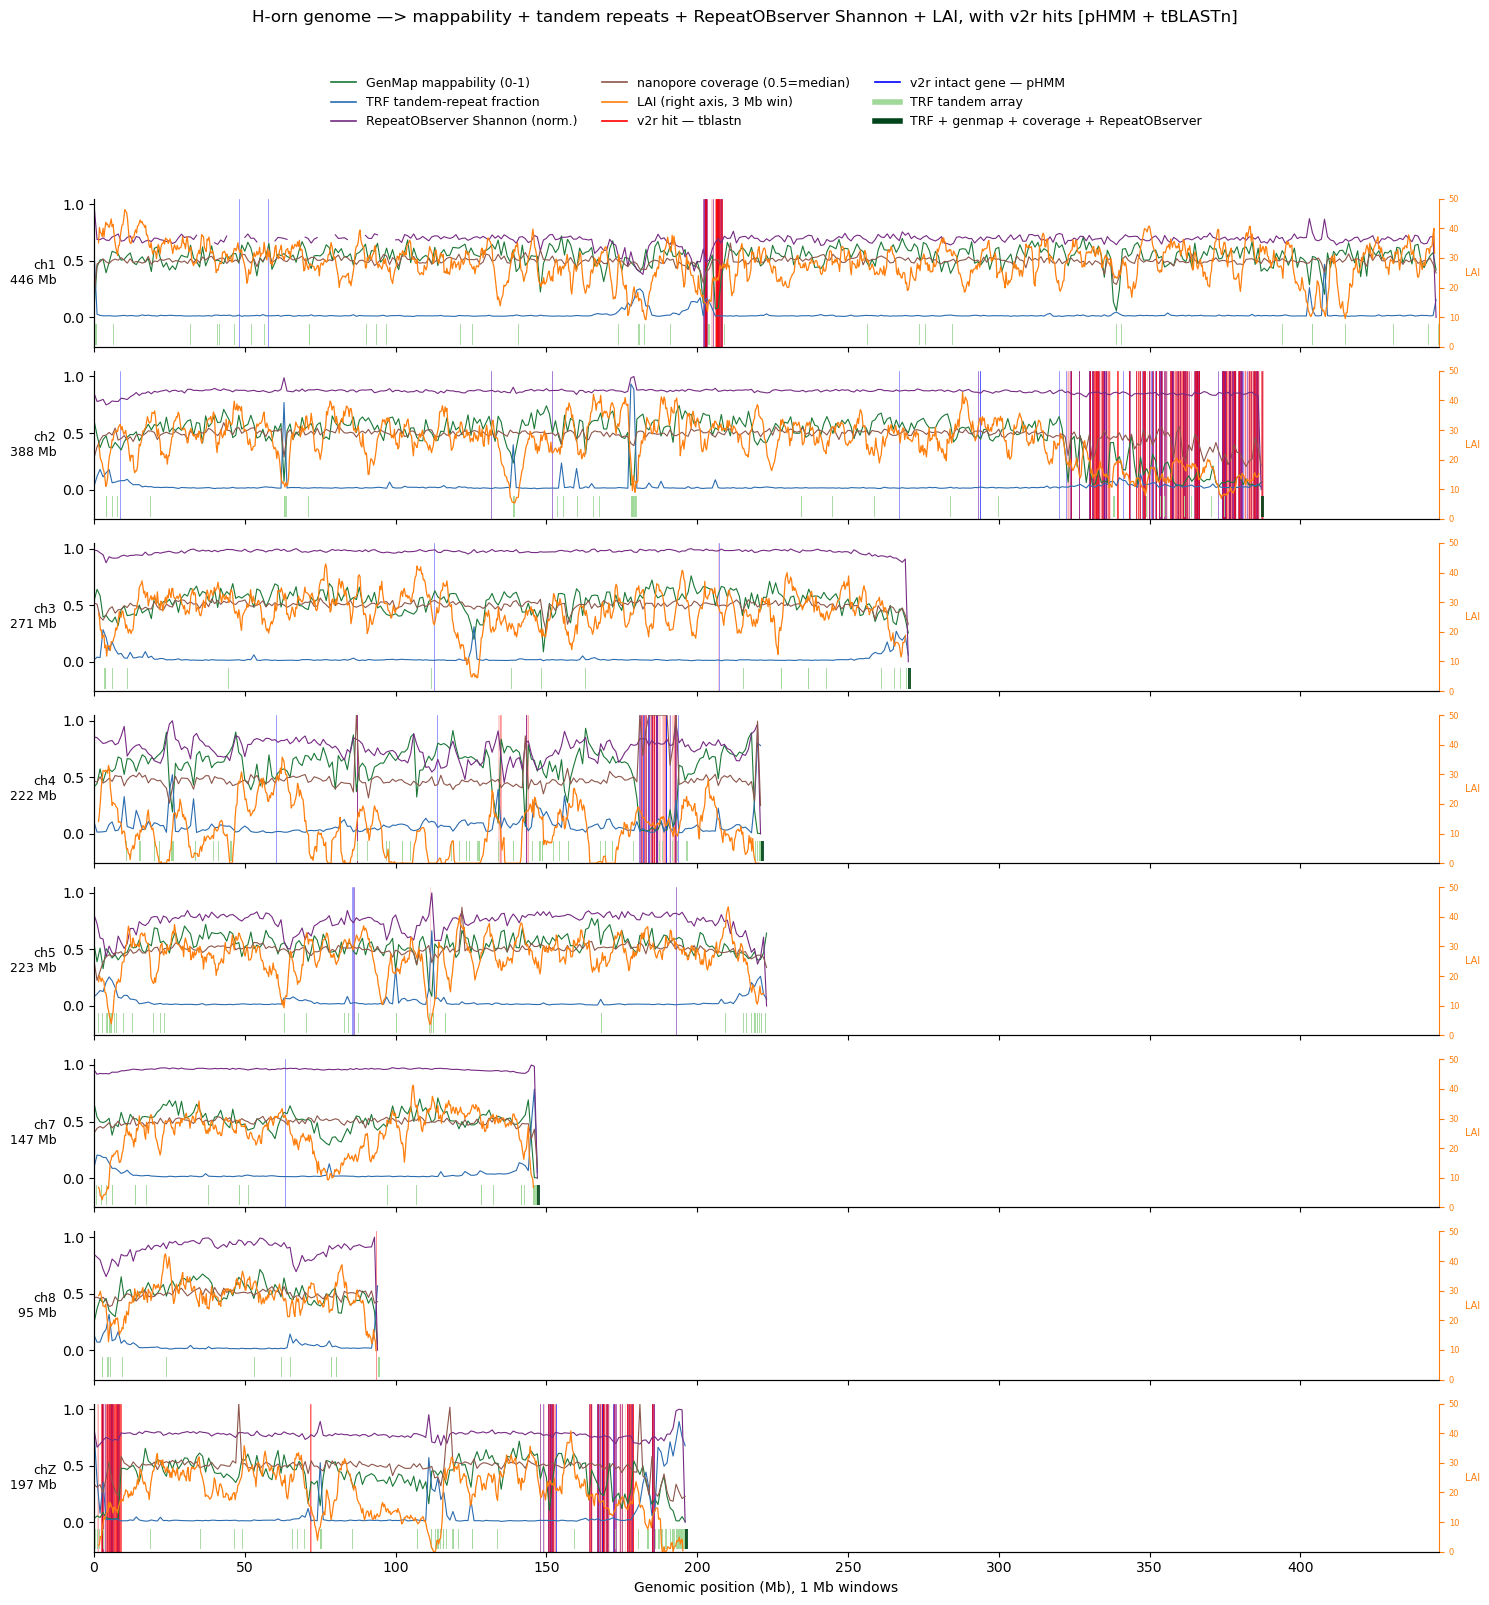

In [77]:
fig, axes = plt.subplots(len(CHROMS), 1, figsize=(15, 2.0*len(CHROMS)), sharex=True)
for ax, c in zip(axes, CHROMS):
    x = np.arange(nbins[c])
    # v2r vertical hit markers (behind tracks)
    for px in v2r_hmm[c]:
        ax.axvline(px, color=PINK, lw=0.4, alpha=0.7, zorder=0)
    for px in v2r_blast[c]:
        ax.axvline(px, color=RED, lw=0.4, alpha=0.3, zorder=1)
    # primary normalised tracks
    ax.plot(x, mapp[c],      color="#1b7837", lw=0.8, zorder=3)
    ax.plot(x, trf[c]/100.0, color="#2b6cb0", lw=0.8, zorder=3)
    ax.plot(x, norm(sha[c]), color="#762a83", lw=0.8, zorder=3)
    # coverage: depth/(2*median) so 0.5 = genome median depth, clipped to axis
    ax.plot(x, np.clip(cov[c]/(2*COV_MED), 0, 1.05), color="#8c564b", lw=0.8, zorder=3)
    plot_ta_track(ax, ta_display[c])
    plot_ta_track(ax, ta_strong_display[c], color=TA_STRONG_COLOR, alpha=0.88, zorder=15)
    ax.set_xlim(0, maxb); ax.set_ylim(min(TA_YBOT - 0.02, -0.05), 1.05)
    ax.set_ylabel(f"{c}\n{length[c]/1e6:.0f} Mb", rotation=0, ha="right", va="center", fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    # LAI on twin axis (real units)
    ax2 = ax.twinx()
    if lai_x[c]:
        ax2.plot(lai_x[c], lai_y[c], color="#ff7f0e", lw=0.9, zorder=2)
    ax2.set_ylim(0, LAI_MAX); ax2.set_xlim(0, maxb)
    ax2.set_ylabel("LAI", rotation=0, ha="left", va="center", fontsize=7, color="#ff7f0e")
    ax2.tick_params(axis="y", labelsize=6, colors="#ff7f0e")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color("#ff7f0e")

axes[-1].xaxis.set_major_formatter(FuncFormatter(mb))
axes[-1].set_xlabel("Genomic position (Mb), 1 Mb windows")

legend_handles = [
    Line2D([0],[0], color="#1b7837", lw=1.2, label="GenMap mappability (0-1)"),
    Line2D([0],[0], color="#2b6cb0", lw=1.2, label="TRF tandem-repeat fraction"),
    Line2D([0],[0], color="#762a83", lw=1.2, label="RepeatOBserver Shannon (norm.)"),
    Line2D([0],[0], color="#8c564b", lw=1.2, label="nanopore coverage (0.5=median)"),
    Line2D([0],[0], color="#ff7f0e", lw=1.2, label="LAI (right axis, 3 Mb win)"),
    Line2D([0],[0], color=RED,  lw=1.2, label="v2r hit — tblastn"),
    Line2D([0],[0], color=PINK, lw=1.2, label="v2r intact gene — pHMM"),
    Line2D([0],[0], color=TA_COLOR, lw=4, label="TRF tandem array"),
    Line2D([0],[0], color=TA_STRONG_COLOR, lw=4, label="TRF + genmap + coverage + RepeatOBserver"),
]
axes[0].legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.9),
               ncol=3, fontsize=9, frameon=False)
fig.suptitle("H-orn genome —> mappability + tandem repeats + RepeatOBserver Shannon + LAI, with v2r hits [pHMM + tBLASTn]", y=1.0, fontsize=12)
fig.tight_layout(rect=[0,0,1,0.98])
out = "combined_mappability_TR_robserver_LAI_v2r.png"
fig.savefig(out, dpi=150)
print("wrote", out)
for c in CHROMS:
    print(f"  {c}: LAI windows={len(lai_x[c])}, tblastn hits={len(v2r_blast[c])}, pHMM hits={len(v2r_hmm[c])}")


## Per-chromosome plots

One figure per chromosome, x-axis scaled to chromosome length. Saved to `per_chrom/{chrom}_tracks.png`.

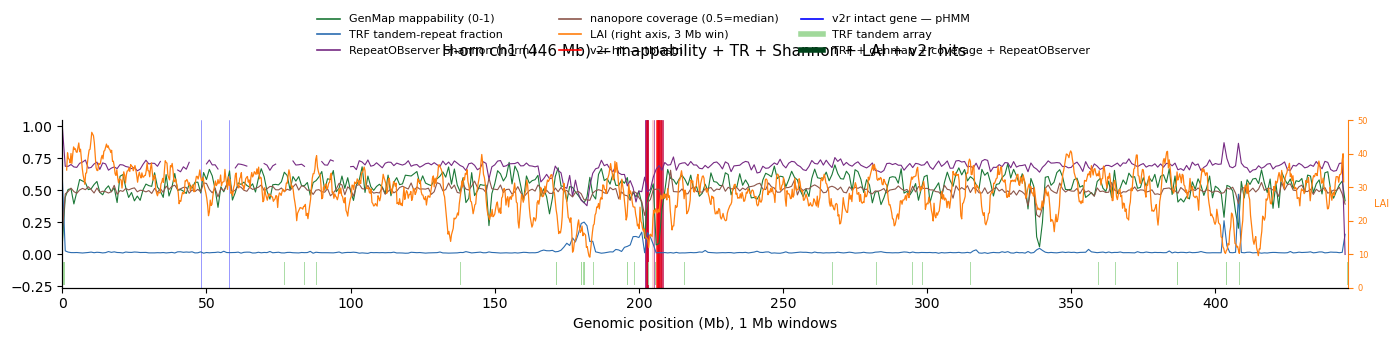

wrote per_chrom/ch1_tracks.png


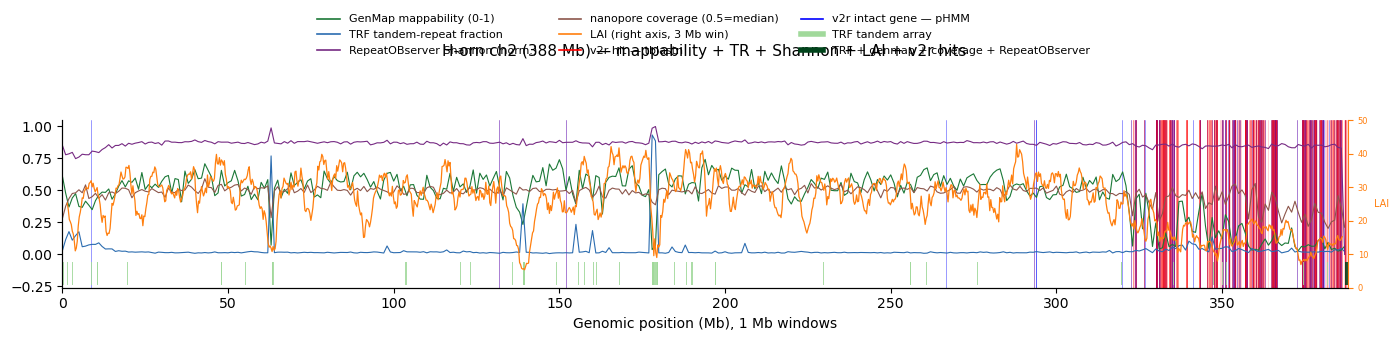

wrote per_chrom/ch2_tracks.png


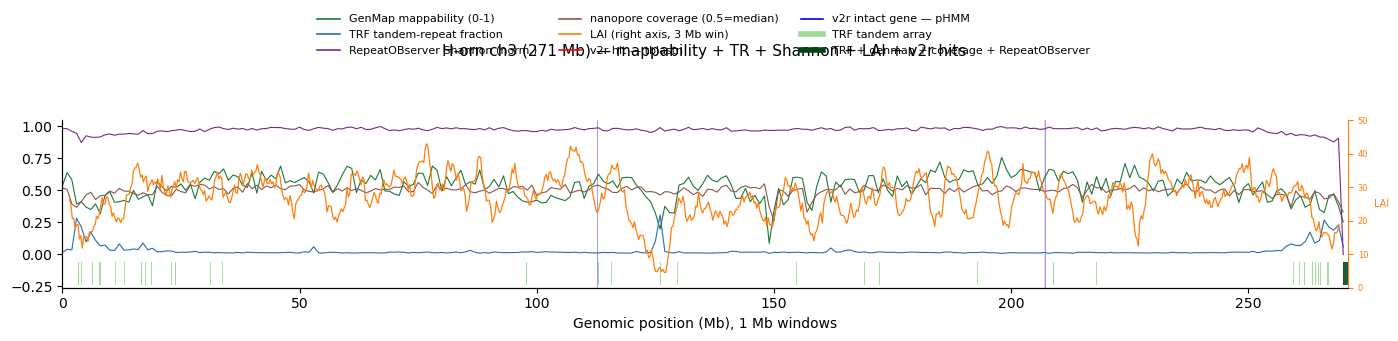

wrote per_chrom/ch3_tracks.png


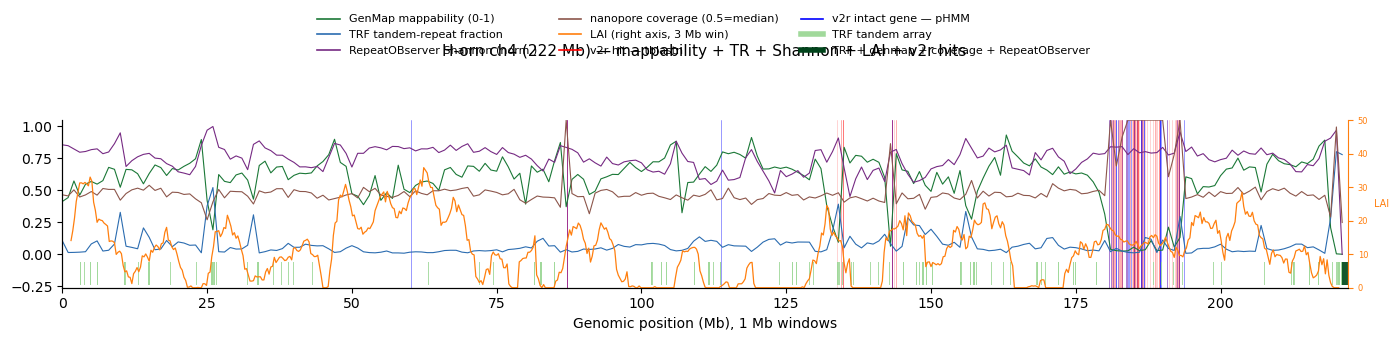

wrote per_chrom/ch4_tracks.png


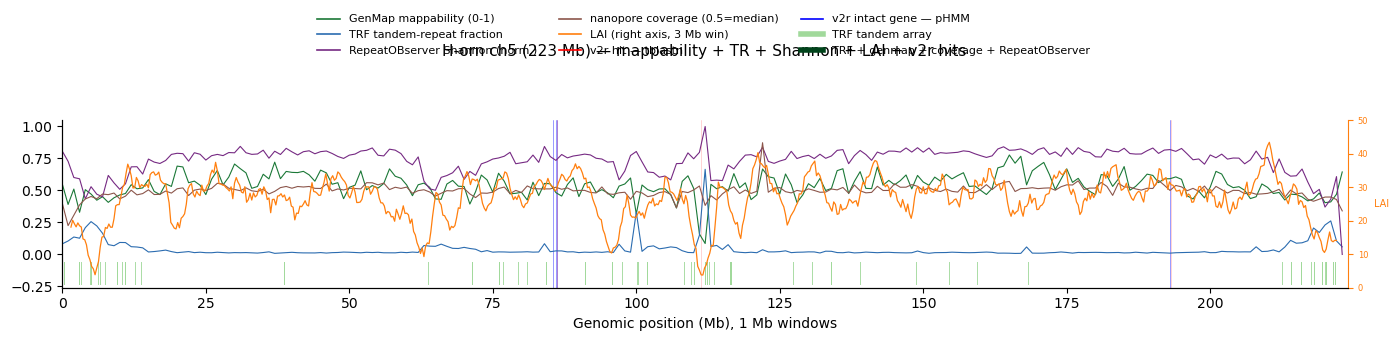

wrote per_chrom/ch5_tracks.png


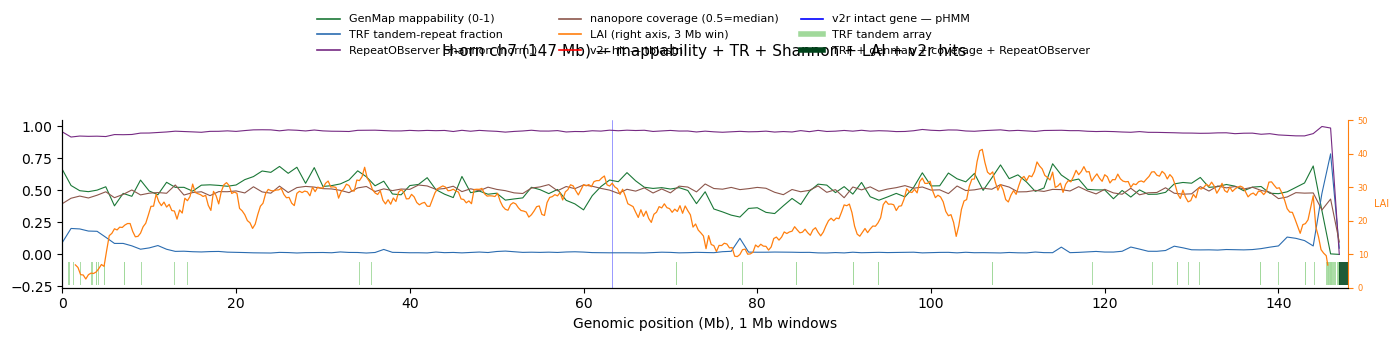

wrote per_chrom/ch7_tracks.png


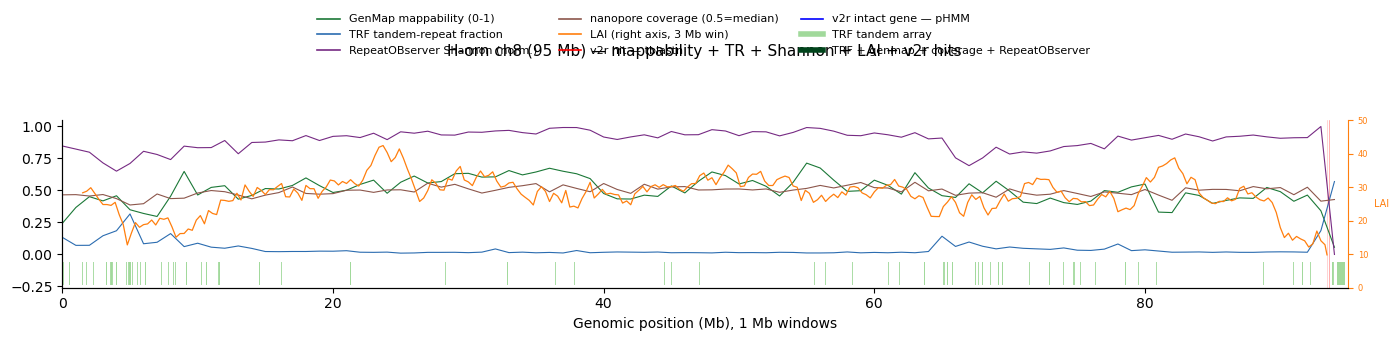

wrote per_chrom/ch8_tracks.png


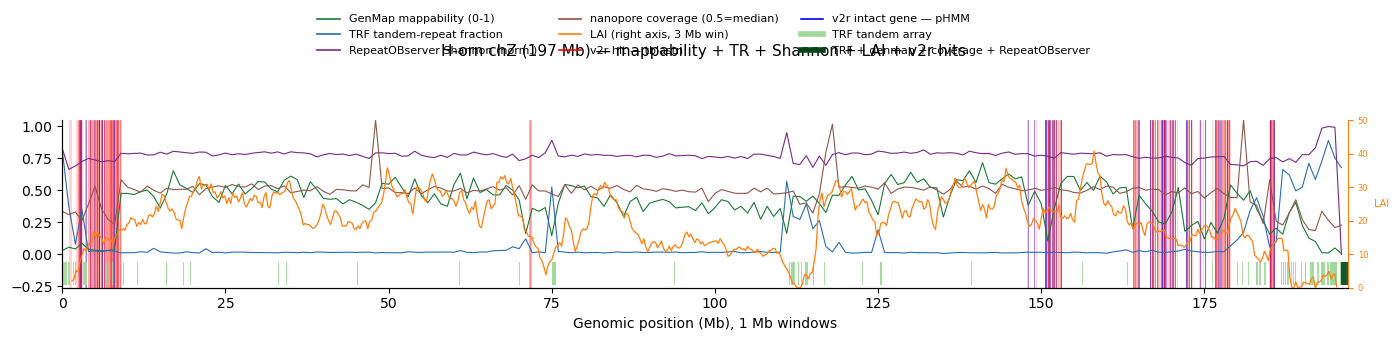

wrote per_chrom/chZ_tracks.png


In [78]:
# per-chromosome plots → per_chrom/{chrom}_tracks.png
import os
os.makedirs("per_chrom", exist_ok=True)

for c in CHROMS:
    fig_c, ax_c = plt.subplots(figsize=(14, 2.8))
    plot_chromosome_panel(ax_c, c, show_ylabel=False)
    ax_c.xaxis.set_major_formatter(FuncFormatter(mb))
    ax_c.set_xlabel("Genomic position (Mb), 1 Mb windows")
    fig_c.legend(handles=LEGEND_HANDLES, loc="upper center", bbox_to_anchor=(0.5, 1.22),
                 ncol=3, fontsize=8, frameon=False)
    fig_c.suptitle(
        f"H-orn {c} ({length[c]/1e6:.0f} Mb) — mappability + TR + Shannon + LAI + v2r hits",
        y=1.08, fontsize=11,
    )
    fig_c.tight_layout(rect=[0, 0, 1, 0.98])
    out_c = f"per_chrom/{c}_tracks.png"
    fig_c.savefig(out_c, dpi=150)
    plt.show()
    print("wrote", out_c)